<a href="https://colab.research.google.com/github/trisskmasarahh/PCVK_Ganjil_2025/blob/main/Modul_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


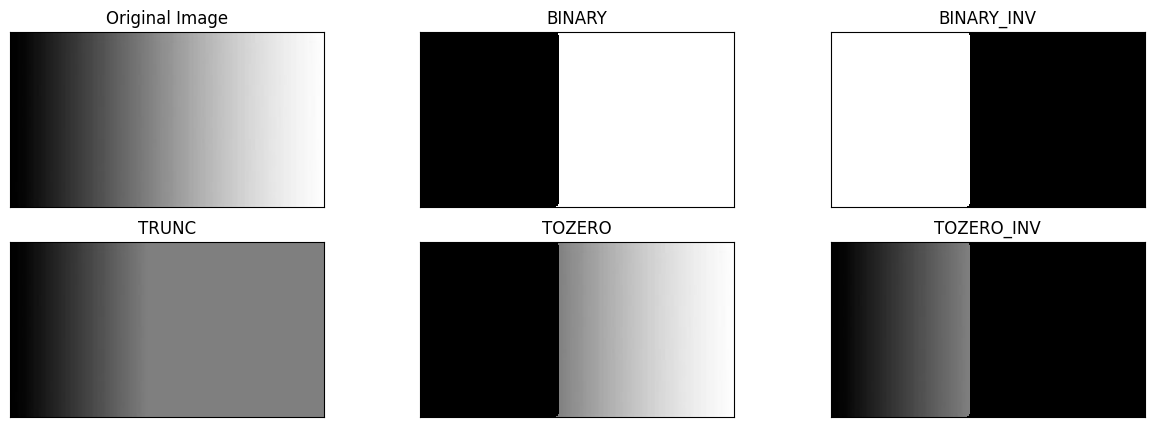

In [4]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

filename = ('/content/drive/MyDrive/PCVK/gradient.jpg')
img = cv.imread(filename)
thresh = 127  #nilai Threshold yang ditentukan

#1. thresh1 jika pixel di img>127, maka thresh1 bernilai 1(putih) selain itu bernilai 0(hitam)
ret,thresh1 = cv.threshold(img,thresh,255,cv.THRESH_BINARY)
#2. thresh2 adalah binary threshold inverse
ret,thresh2 = cv.threshold(img,thresh,255,cv.THRESH_BINARY_INV)
#3. Threshold Truncate
ret,thresh3 = cv.threshold(img,thresh,255,cv.THRESH_TRUNC)
#4. Threshold Tozero
ret,thresh4 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO)
#5. Threshold Tozero Inverse
ret,thresh5 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize = (15,5))
for i in range(len(images)):
  plt.subplot(2,3,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])
plt.show()

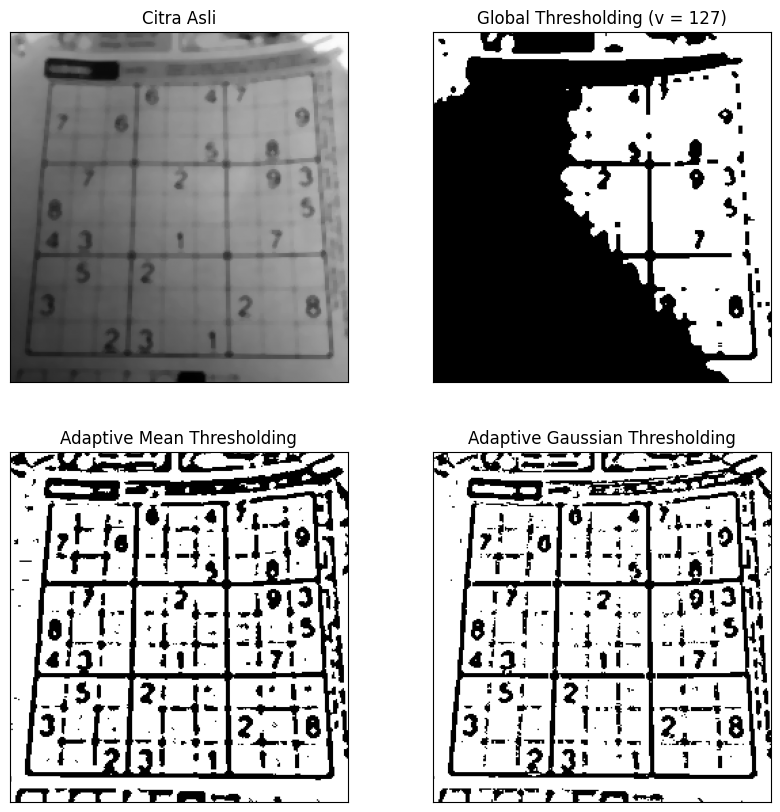

In [5]:
filename = ('/content/drive/MyDrive/PCVK/s udoku-original.jpg')
citra = cv.medianBlur(cv.imread(filename),5)
gray = cv.cvtColor(citra, cv.COLOR_BGR2GRAY)
#gray = cv.medianBlur(gray,5)

thresh = 127

ret,th1 = cv.threshold(gray,thresh,255,cv.THRESH_BINARY)
th2 = cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY,11,2)
th3 = cv.adaptiveThreshold(gray,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY,11,2)

titles = ['Citra Asli', 'Global Thresholding (v = 127)', 'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
citra2 = [gray, th1, th2, th3]

plt.figure(figsize = (10,10))
for i in range(len(citra2)):
    plt.subplot(2,2,i+1),plt.imshow(citra2[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

/tmp/ipython-input-2850516486.py:14: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(2,2,1),plt.hist(blur.ravel(),256,[50,200])


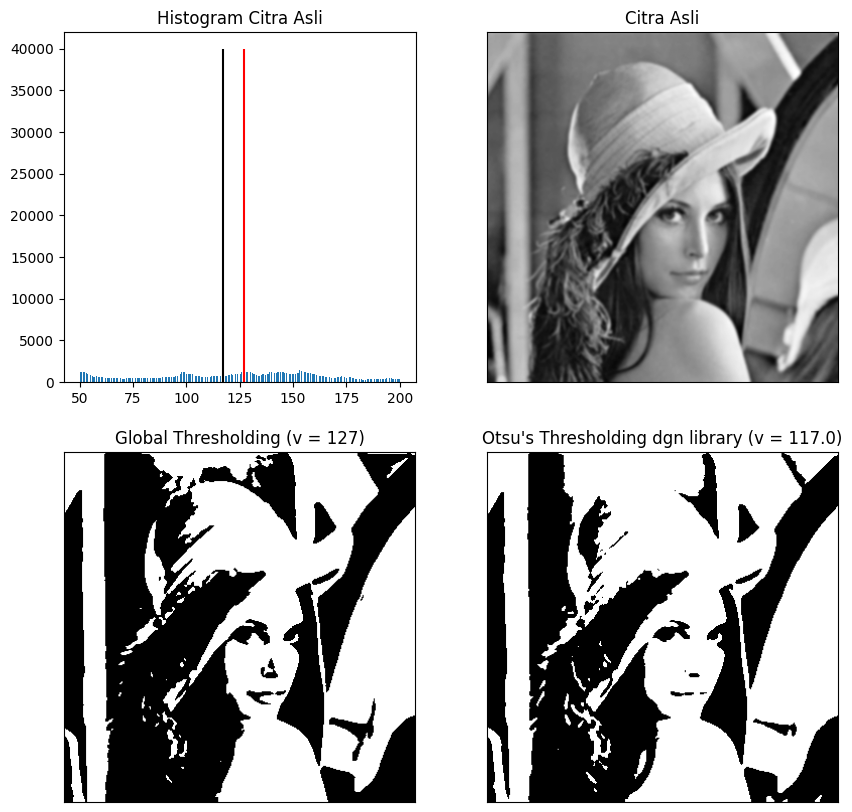

In [6]:
filename = ('/content/drive/MyDrive/PCVK/Lena.jpg')
img = cv.imread(filename,0)
blur = cv.GaussianBlur(img,(5,5),0)
thresh = 127

ret,th1 = cv.threshold(blur,thresh,255,cv.THRESH_BINARY)
ret2,th2 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)

x = ("Otsu's Thresholding dgn library (v = ")+str(ret2)+")"
titles = ['Citra Asli', 'Global Thresholding (v = 127)', x]
citra3 = [blur, th1, th2]

plt.figure(figsize = (10,10))
plt.subplot(2,2,1),plt.hist(blur.ravel(),256,[50,200])
plt.vlines(ret,0,40000,colors='red')     #garis vertikal merah menunjukan threshold global 127
plt.vlines(ret2,0,40000,colors='black')  #garis vertikal hitam menunjukkan threshold 92 hasil otsu's
plt.title('Histogram Citra Asli')
for i in range(len(citra3)):
    plt.subplot(2,2,i+2),plt.imshow(citra3[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()

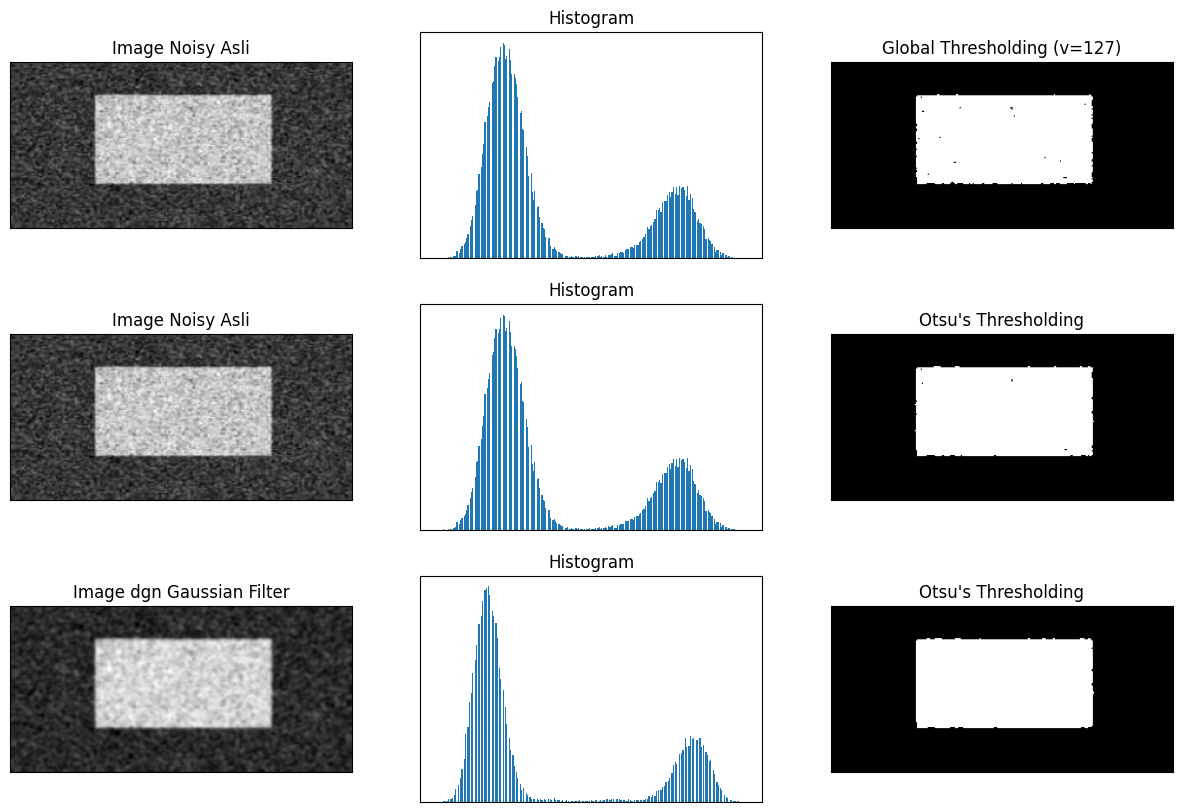

In [7]:
filename = ('/content/drive/MyDrive/PCVK/noi sy2.jpg')
img = cv.imread(filename,0)

#Global Thresholding
ret1,th1 = cv.threshold(img,127,255,cv.THRESH_BINARY)
# Otsu's thresholding
ret2,th2 = cv.threshold(img,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
# Otsu's thresholding setelah dilakukan Gaussian filtering
blur = cv.GaussianBlur(img,(5,5),0)
ret3,th3 = cv.threshold(blur,0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)
#plotting semua image
images = [img, 0, th1,
          img, 0, th2,
          blur, 0, th3]
titles = ['Image Noisy Asli','Histogram','Global Thresholding (v=127)',
          'Image Noisy Asli','Histogram',"Otsu's Thresholding",
          'Image dgn Gaussian Filter','Histogram',"Otsu's Thresholding"]
plt.figure(figsize = (15,10))
for i in range(3):
    plt.subplot(3,3,i*3+1),plt.imshow(images[i*3],'gray')
    plt.title(titles[i*3]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+2),plt.hist(images[i*3].ravel(),256)
    plt.title(titles[i*3+1]), plt.xticks([]), plt.yticks([])
    plt.subplot(3,3,i*3+3),plt.imshow(images[i*3+2],'gray')
    plt.title(titles[i*3+2]), plt.xticks([]), plt.yticks([])
plt.show()

(<Axes: >, <matplotlib.image.AxesImage at 0x7a925620bad0>)

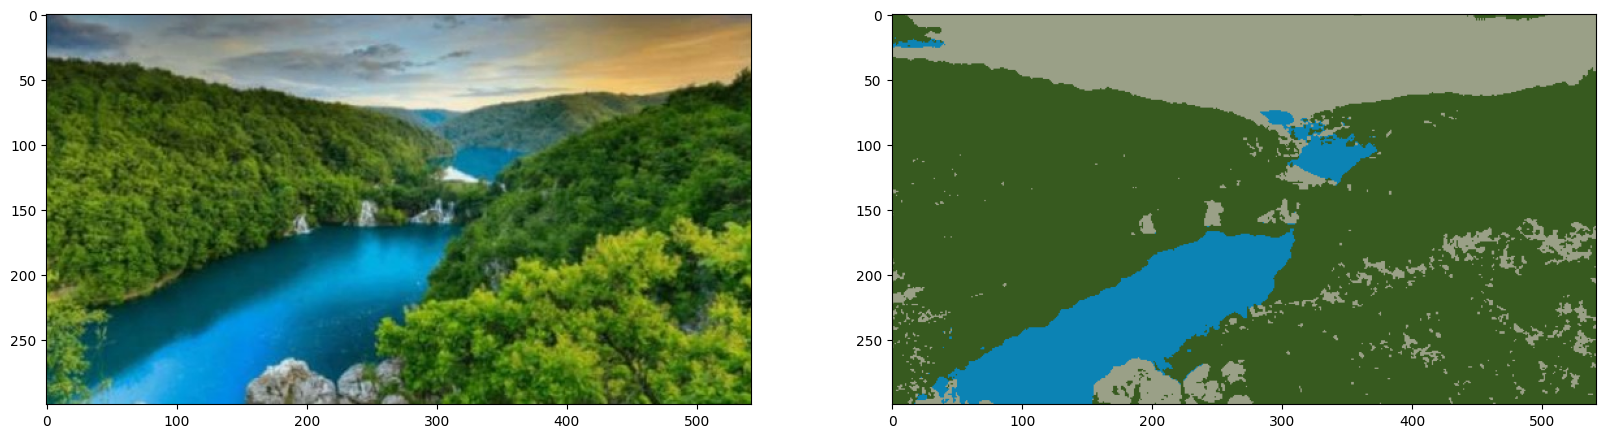

In [8]:
filename = ('/content/drive/MyDrive/PCVK/jungle.jpg')
img = cv.imread(filename)
img = cv.cvtColor(img,cv.COLOR_BGR2RGB)
'''
kita akan menggunakan fungsi cv.kmeans() yang meminta array 2D sebagai masu
 kan, sedangkan image aslinya adalah array 3D
selanjutnya kita perlu melakukan flattening array image masukan
'''
#reshape array ke bentuk 2D
pixel_values = img.reshape((-1, 3))
# convert to float
pixel_values = np.float32(pixel_values)

'''
syarat berhenti iterasi dr KMeans adalah jika centroid sudah tidak terlalu
banyak pergeseran posisi antara interasi sekarang
dengan iterasi sebelumnya (konvergen). Karena jumlah data yang besar, maka
kita akan hentikan iterasi saat jumlah iterasi = 100
atau epsilon(selisih antara posisi centroid skrg dgn posisi centroid di ite
 rasi sebelumnya) < 0.2
'''
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
'''
jika diperhatikan pada image asli, terdapat 3 warna utama (hijau, biru, dan
 putih/orange). untuk percobaan ini kita akan gunakan
3 cluster untuk image ini
'''
k = 3
_, labels, (centers) = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
#konversi titik centroid kedalam integer
centers = np.uint8(centers)
#flattening label array
labels = labels.flatten()
#konversi warna pixel asli kewarna dari tiap centroidnya
segmented_image = centers[labels.flatten()]
# reshape ke bentuk image asli
segmented_image = segmented_image.reshape(img.shape)
plt.figure(figsize = (20,20))
plt.subplot(1,2,1),plt.imshow(img)
plt.subplot(1,2,2),plt.imshow(segmented_image)

(<Axes: >, <matplotlib.image.AxesImage at 0x7a9256498cb0>)

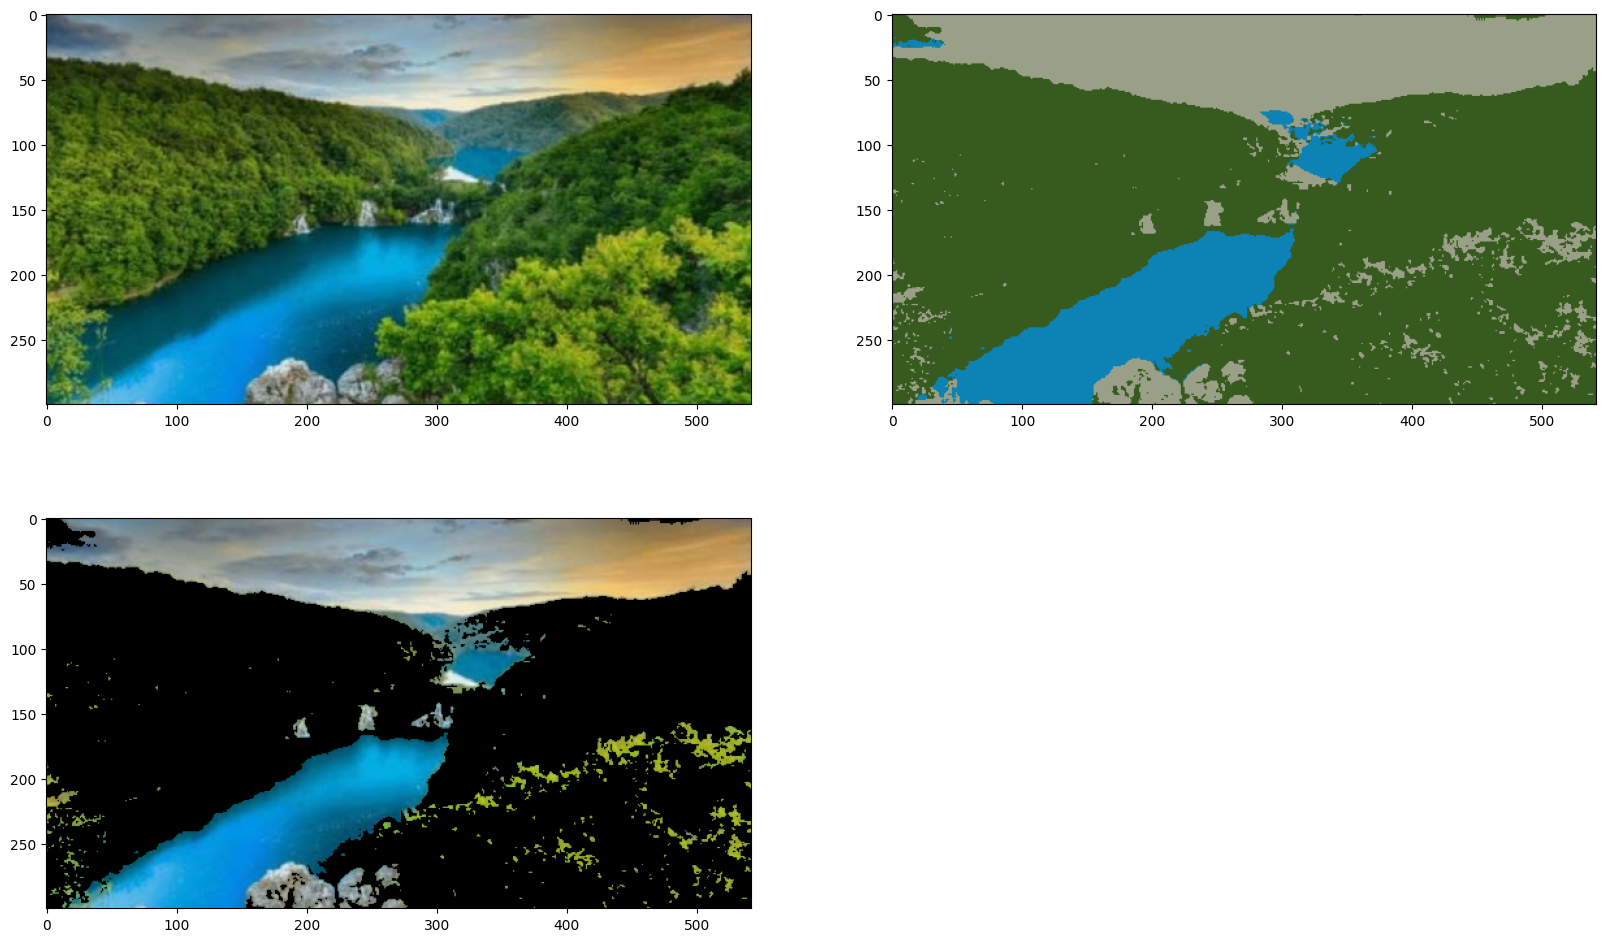

In [9]:
# ubah pixel di cluster 2 menjadi hitam
masked_image = np.copy(img)
# konvert ke bentuk vektor
masked_image = masked_image.reshape((-1, 3))
# cluster yang diubah
cluster = 2
masked_image[labels == cluster] = [0, 0, 0]
# konvert ke bentuk asli
masked_image = masked_image.reshape(img.shape)

plt.figure(figsize = (20,12))
plt.subplot(2,2,1),plt.imshow(img)
plt.subplot(2,2,2),plt.imshow(segmented_image)
plt.subplot(2,2,3),plt.imshow(masked_image)

# TUGAS

In [10]:
# soal 2: Impor library yang diperlukan
import cv2
import numpy as np
from matplotlib import pyplot as plt


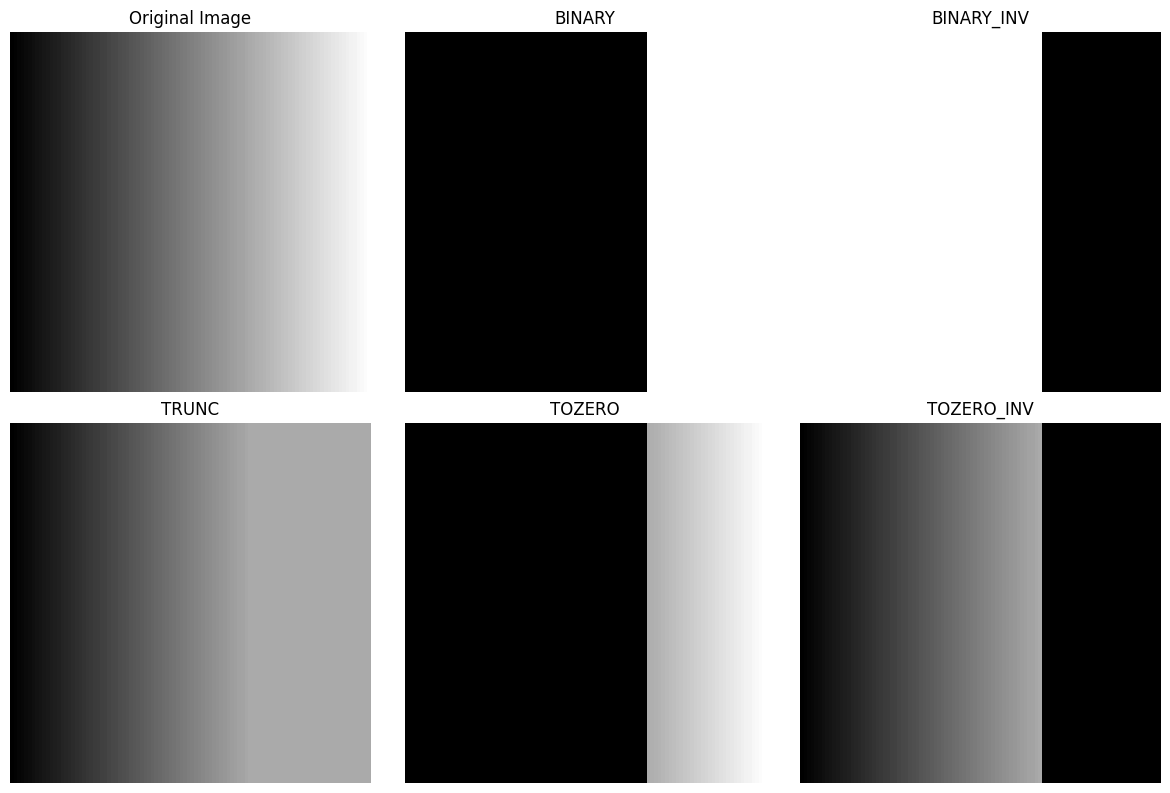

In [11]:
# soal 3
# Simulasi array citra asli (gradien horizontal dari 0 hingga 255)
x, y = np.meshgrid(np.linspace(0, 255, 100), np.linspace(0, 255, 100))
original = np.clip(x, 0, 255).astype(np.uint8)  # Menggunakan hanya x untuk gradien horizontal

# Nilai threshold
threshold = 170

# Aplikasi thresholding secara manual
binary = np.where(original > threshold, 255, 0)  # BINARY
binary_inv = np.where(original > threshold, 0, 255)  # BINARY_INV
trunc = np.where(original > threshold, threshold, original)  # TRUNC
tozero = np.where(original > threshold, original, 0)  # TOZERO
tozero_inv = np.where(original <= threshold, original, 0)  # TOZERO_INV

# Tampilkan hasil secara vertikal
titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [original, binary, binary_inv, trunc, tozero, tozero_inv]

plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


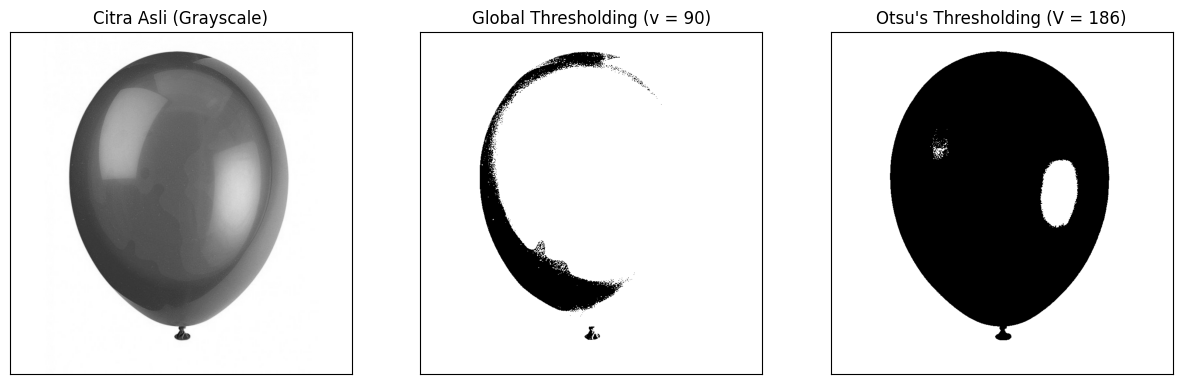

In [12]:
from google.colab import drive
drive.mount('/content/drive')

# Membaca file path
file_path = '/content/drive/MyDrive/PCVK/balloon.jpg'

# Muat gambar asli (berwarna)
img_color = cv2.imread(file_path)

# Mengubah gambar ke Grayscale ---
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)


# lobal Thresholding (dijalankan pada gambar grayscale)
ret_global, global_thresh = cv2.threshold(img_gray, 90, 255, cv2.THRESH_BINARY)

# Implementasi Manual Otsu's Thresholding (dijalankan pada gambar grayscale)
def otsu_manual(image):
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist_norm = hist.ravel() / hist.sum()

    max_variance = 0
    optimal_thresh = 0

    for t in range(1, 256):
        w_b = np.sum(hist_norm[:t])
        w_f = np.sum(hist_norm[t:])

        if w_b == 0 or w_f == 0:
            continue

        mean_b = np.sum(np.arange(t) * hist_norm[:t]) / w_b
        mean_f = np.sum(np.arange(t, 256) * hist_norm[t:]) / w_f

        between_variance = w_b * w_f * (mean_b - mean_f) ** 2

        if between_variance > max_variance:
            max_variance = between_variance
            optimal_thresh = t

    return int(optimal_thresh)

# Dapatkan nilai threshold dari fungsi Otsu manual
otsu_thresh_val = otsu_manual(img_gray)

# Terapkan threshold hasil Otsu ke gambar
ret_otsu, otsu_thresh_img = cv2.threshold(img_gray, otsu_thresh_val, 255, cv2.THRESH_BINARY)

# Menampilkan semua hasil
# Citra Asli yang ditampilkan adalah versi grayscale
titles = [
    'Citra Asli (Grayscale)',
    'Global Thresholding (v = 90)',
    f"Otsu's Thresholding (V = {otsu_thresh_val})"
]
images = [img_gray, global_thresh, otsu_thresh_img]

plt.figure(figsize=(15, 5))
for i in range(len(images)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


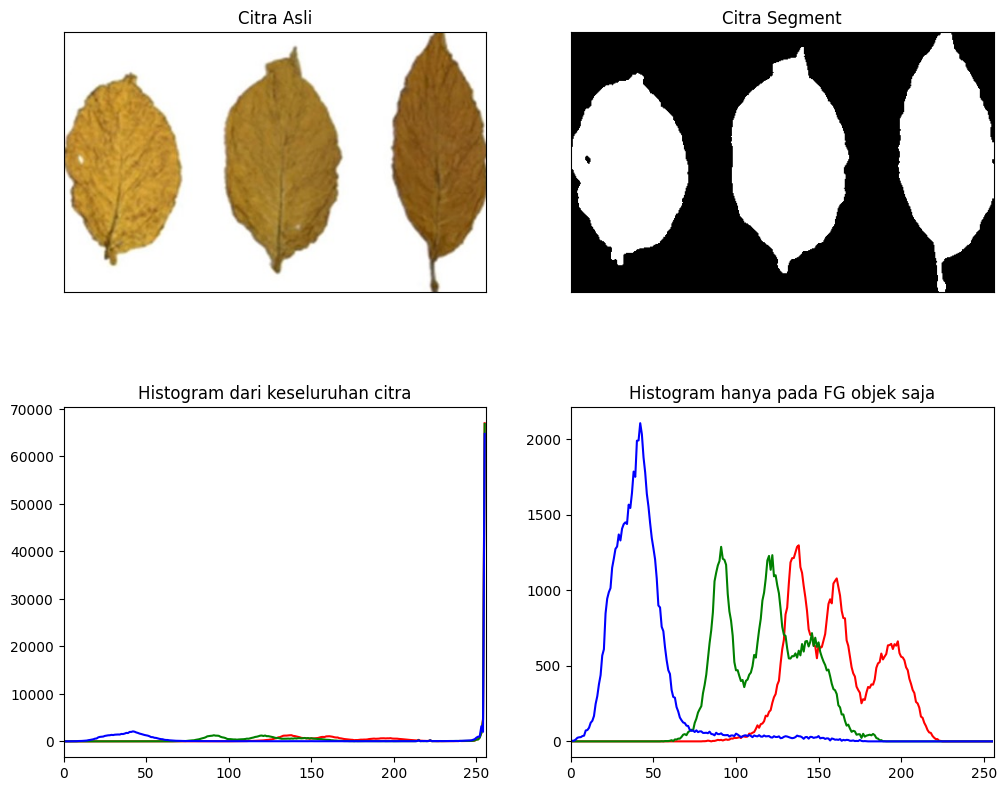

In [13]:
from google.colab import drive
drive.mount('/content/drive')

# Membaca file path
file_path = '/content/drive/MyDrive/PCVK/Daun.jpg'

# Muat gambar berwarna dari path yang sudah benar
img_color = cv2.imread(file_path)

# Konversi ke RGB untuk plotting yang benar di Matplotlib
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

# Membuat Mask (Citra Segment)
# Ubah ke grayscale untuk memudahkan thresholding
img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
# Gunakan Otsu's Thresholding terbalik untuk memisahkan daun (gelap) dari background (putih)
# Hasilnya adalah mask di mana daun berwarna putih (255) dan background hitam (0)
ret, mask = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Menghtung histogram
colors = ('r', 'g', 'b') # Urutan channel untuk Matplotlib RGB

# Plotting
plt.figure(figsize=(12, 10))

# Panel 1: Citra Asli
plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.xticks([]), plt.yticks([])

# Panel 2: Citra Segment (Mask)
plt.subplot(2, 2, 2)
plt.imshow(mask, 'gray')
plt.title('Citra Segment')
plt.xticks([]), plt.yticks([])

# Panel 3: Histogram Keseluruhan Citra
plt.subplot(2, 2, 3)
# Hitung dan plot histogram untuk setiap channel BGR dari gambar asli
for i, col in enumerate(colors):
    # Perhatikan urutan channel cv2 adalah BGR (0,1,2), kita plot sebagai RGB
    hist_full = cv2.calcHist([img_color], [2-i], None, [256], [0, 256])
    plt.plot(hist_full, color=col)
plt.xlim([0, 256])
plt.title('Histogram dari keseluruhan citra')

# Panel 4: Histogram Foreground Saja
plt.subplot(2, 2, 4)
# Hitung dan plot histogram dengan menggunakan mask
for i, col in enumerate(colors):
    hist_masked = cv2.calcHist([img_color], [2-i], mask, [256], [0, 256])
    plt.plot(hist_masked, color=col)
plt.xlim([0, 256])
plt.title('Histogram hanya pada FG objek saja')

plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


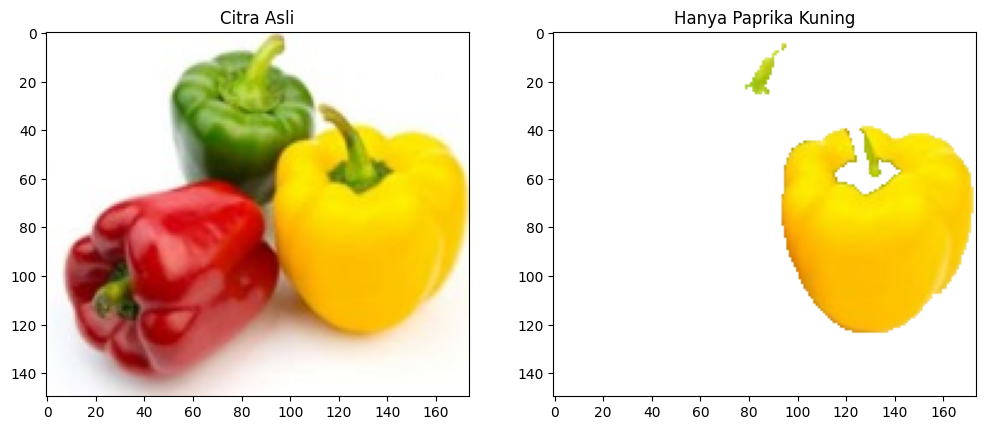

In [14]:
from google.colab import drive
drive.mount('/content/drive')

# Membaca file path
file_path = '/content/drive/MyDrive/PCVK/Paprika.jpg'

# Muat gambar berwarna dari path
img_color = cv2.imread(file_path)

# Konversi dari BGR ke RGB
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

# Persiapkan data untuk K-Means
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# Menjalankan Algoritma K-Means
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 5
_, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)

# Mengidentifikasi dan Isolasi Cluster Kuning
yellow_color = np.array([255, 255, 0])
distances = np.linalg.norm(centers - yellow_color, axis=1)
yellow_cluster_index = np.argmin(distances)

masked_data = np.copy(pixel_values)
masked_data[labels.flatten() != yellow_cluster_index] = [255, 255, 255]

masked_image = masked_data.reshape(img_rgb.shape)
masked_image = np.uint8(masked_image)

# Tampilkan hasil
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')

plt.subplot(1, 2, 2)
plt.imshow(masked_image)
plt.title('Hanya Paprika Kuning')
plt.show()

Saat anda menampilkan warna tertentu, jelaskan kendala yang di hadapi dan mengapa hal itu terjadi.

Saat mencoba mengisolasi warna tertentu menggunakan K-Means, seperti pada kasus paprika kuning, beberapa kendala fundamental akan muncul karena cara kerja algoritma itu sendiri. Masalah utamanya adalah variasi pencahayaan dan bayangan. Algoritma K-Means tidak memahami konsep "objek", melainkan hanya mengelompokkan piksel berdasarkan nilai numerik warnanya. Akibatnya, area terang pada paprika karena pantulan cahaya dan area gelap karena bayangan dianggap sebagai warna yang berbeda, sehingga K-Means dapat menempatkannya ke dalam cluster yang terpisah. Hal ini menyebabkan hasil segmentasi objek menjadi tidak utuh atau "bolong-bolong".

Kendala ini berhubungan langsung dengan tantangan kedua, yaitu pemilihan jumlah cluster (k) yang tepat. Jika nilai k terlalu besar untuk mengakomodasi semua variasi warna, satu paprika kuning itu sendiri bisa terpecah menjadi beberapa cluster (misalnya, "kuning terang" dan "kuning gelap"), yang membuat proses isolasi menjadi lebih rumit. Sebaliknya, jika k terlalu kecil, warna yang berbeda namun mirip—seperti kuning dan hijau—bisa dipaksa masuk ke dalam satu cluster yang sama.

Terakhir, K-Means tidak memiliki pemahaman spasial, yang menimbulkan masalah kedekatan warna antar objek. Contohnya, batang hijau pada paprika kuning akan dikelompokkan bersama paprika hijau karena warnanya lebih mirip, sehingga bagian tersebut hilang dari hasil akhir. Secara keseluruhan, kendala-kendala ini menunjukkan bahwa K-Means adalah alat yang kuat untuk pengelompokan warna secara matematis, namun tidak memiliki pemahaman kontekstual seperti manusia, sehingga hasilnya seringkali merupakan aproksimasi yang tidak sempurna dari objek sebenarnya.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


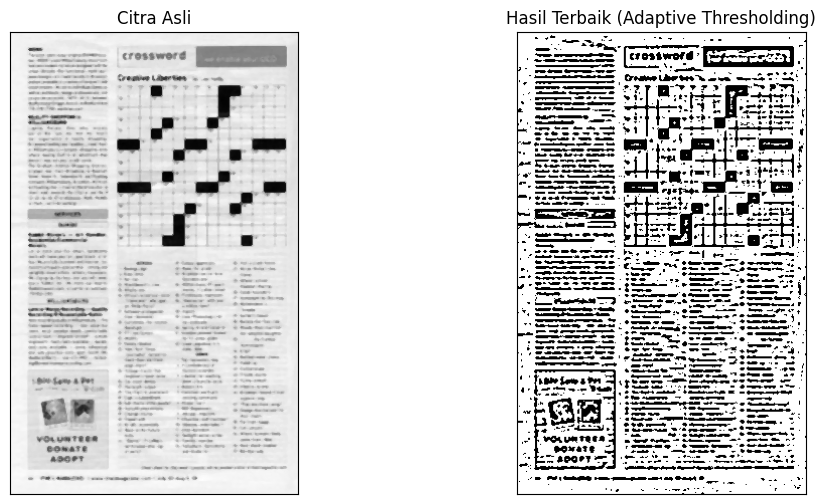

In [15]:
from google.colab import drive
drive.mount('/content/drive')

# Membaca file path
file_path = '/content/drive/MyDrive/PCVK/Crossword.jpg'

# Muat gambar dari path yang sudah benar
img = cv2.imread(file_path, 0)

# Pastikan gambar tidak blur untuk hasil yang lebih tajam
img = cv2.medianBlur(img, 3)

# Terapkan Adaptive Thresholding
# Parameter:
# - img: Gambar input
# - 255: Nilai maksimum yang diberikan jika piksel memenuhi syarat
# - cv2.ADAPTIVE_THRESH_GAUSSIAN_C: Metode thresholding adaptif [cite: 134]
# - cv2.THRESH_BINARY: Tipe threshold biner
# - 11: Ukuran blok area (Block Size) untuk menghitung threshold
# - 2: Konstanta C yang dikurangkan dari hasil perhitungan rata-rata atau bobot [cite: 135]
adaptive_thresh = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                          cv2.THRESH_BINARY, 11, 2)

# Tampilkan hasil
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img, 'gray')
plt.title('Citra Asli')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2)
plt.imshow(adaptive_thresh, 'gray')
plt.title('Hasil Terbaik (Adaptive Thresholding)')
plt.xticks([]), plt.yticks([])

plt.show()
